# 05 — Player Box-Score Features

**Ziel:** Aus `PlayerStatistics.csv` zusaetzliche Team-Features ableiten — Schiessquoten, Plus/Minus, Turnovers etc. — und schauen, ob das Modell besser wird.

**Strategie:**
1. PlayerStatistics auf **Team-Game-Ebene** aggregieren (pro Team pro Spiel ein Eintrag mit Summen/Schnitten)
2. Pro Team **rollierende Schnitte** der letzten 10 Spiele berechnen — wieder mit `.shift()` gegen Leakage
3. Diese Features in unseren bestehenden Datensatz mergen
4. XGBoost neu trainieren und gegen das alte Modell vergleichen

**Was wir uns sparen (zunaechst):** Star-Verfuegbarkeit / Verletzte. Ohne saubere Injury-Daten ist das Leak-anfaellig — Future Work.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, roc_auc_score
import xgboost as xgb

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_RAW = Path('..') / 'data' / 'raw'
DATA_PROCESSED = Path('..') / 'data' / 'processed'

games = pd.read_parquet(DATA_PROCESSED / 'games_with_features.parquet')
print(f'Games (mit alten Features): {len(games):,}')

Games (mit alten Features): 71,239


## 2. PlayerStatistics laden

Das ist die groesste Datei — eine Zeile pro Spieler pro Spiel. Wir laden nur die Spalten, die wir brauchen, um Speicher zu sparen.

In [2]:
use_cols = [
    'gameId', 'playerteamId', 'numMinutes',
    'points', 'assists', 'reboundsTotal', 'turnovers',
    'fieldGoalsAttempted', 'fieldGoalsMade',
    'threePointersAttempted', 'threePointersMade',
    'freeThrowsAttempted', 'freeThrowsMade',
    'plusMinusPoints', 'steals', 'blocks',
]
ps = pd.read_csv(DATA_RAW / 'PlayerStatistics.csv', usecols=use_cols)
print(f'Player-Game-Zeilen: {len(ps):,}')
ps.head(3)

Player-Game-Zeilen: 1,668,357


C:\Users\Uni\AppData\Local\Temp\ipykernel_11132\3952411079.py:9: DtypeWarning: Columns (0: playerteamId) have mixed types. Specify dtype option on import or set low_memory=False.
  ps = pd.read_csv(DATA_RAW / 'PlayerStatistics.csv', usecols=use_cols)


,gameId,numMinutes,points,assists,blocks,steals,fieldGoalsAttempted,fieldGoalsMade,threePointersAttempted,threePointersMade,freeThrowsAttempted,freeThrowsMade,reboundsTotal,turnovers,plusMinusPoints,playerteamId
0,42500174,15.4,5.0,4.0,0.0,0.0,5.0,2.0,4.0,1.0,0.0,0.0,2.0,1.0,-1.0,1.610613e+09
1,42500174,7.416667,5.0,0.0,1.0,0.0,5.0,2.0,3.0,1.0,0.0,0.0,0.0,1.0,4.0,1.610613e+09
2,42500174,32.25,7.0,2.0,0.0,0.0,8.0,3.0,3.0,0.0,1.0,1.0,3.0,2.0,-13.0,1.610613e+09


## 3. Auf Team-Game-Ebene aggregieren

Pro `(gameId, playerteamId)`:
- **Summen:** Punkte, Assists, Rebounds, Turnovers, Steals, Blocks, FG-Versuche/Treffer etc.
- **Abgeleitet:** Team-FG%, 3P%, FT%
- **Top-3 Minuten:** durchschnittliche Plus/Minus der drei Spieler mit den meisten Minuten — Proxy fuer Star-Performance

Eigentliche Aggregation in zwei Schritten, weil die Top-3-Berechnung pro Gruppe etwas mehr Logik braucht.

In [3]:
# Schritt A: einfache Summen
team_box = ps.groupby(['gameId', 'playerteamId'], as_index=False).agg(
    pts=('points', 'sum'),
    ast=('assists', 'sum'),
    reb=('reboundsTotal', 'sum'),
    tov=('turnovers', 'sum'),
    stl=('steals', 'sum'),
    blk=('blocks', 'sum'),
    fga=('fieldGoalsAttempted', 'sum'),
    fgm=('fieldGoalsMade', 'sum'),
    tpa=('threePointersAttempted', 'sum'),
    tpm=('threePointersMade', 'sum'),
    fta=('freeThrowsAttempted', 'sum'),
    ftm=('freeThrowsMade', 'sum'),
    n_players=('points', 'count'),
)

# Abgeleitete Quoten (mit Schutz vor Division durch 0)
team_box['fg_pct'] = (team_box.fgm / team_box.fga.replace(0, np.nan)).fillna(0)
team_box['tp_pct'] = (team_box.tpm / team_box.tpa.replace(0, np.nan)).fillna(0)
team_box['ft_pct'] = (team_box.ftm / team_box.fta.replace(0, np.nan)).fillna(0)

# Schritt B: Top-3-Plus/Minus (durchschnittlicher PM der 3 Spieler mit meisten Minuten)
ps_sorted = ps.sort_values(['gameId', 'playerteamId', 'numMinutes'], ascending=[True, True, False])
top3 = ps_sorted.groupby(['gameId', 'playerteamId']).head(3)
top3_pm = top3.groupby(['gameId', 'playerteamId'], as_index=False).agg(top3_pm=('plusMinusPoints', 'mean'))
team_box = team_box.merge(top3_pm, on=['gameId', 'playerteamId'], how='left')

print(f'Team-Game-Eintraege: {len(team_box):,} (erwartet ~2 x #Spiele = ~{2 * games.gameId.nunique():,})')
team_box.head(3)

Team-Game-Eintraege: 138,966 (erwartet ~2 x #Spiele = ~142,478)


,gameId,playerteamId,pts,ast,reb,tov,stl,blk,fga,fgm,tpa,tpm,fta,ftm,n_players,fg_pct,tp_pct,ft_pct,top3_pm
0,20000593,1.610613e+09,82.0,24.0,40.0,20.0,12.0,11.0,71.0,33.0,8.0,2.0,20.0,14.0,12,0.464789,0.250000,0.700000,3.000000
1,20000593,1.610613e+09,73.0,23.0,41.0,19.0,13.0,5.0,80.0,31.0,8.0,1.0,17.0,10.0,12,0.387500,0.125000,0.588235,-8.333333
2,20000596,1.610613e+09,105.0,30.0,46.0,11.0,6.0,9.0,79.0,35.0,19.0,11.0,32.0,24.0,12,0.443038,0.578947,0.750000,3.666667


## 4. Mit Game-Datum verknuepfen + nach Team/Datum sortieren

In [4]:
team_box = team_box.merge(
    games[['gameId', 'gameDate', 'season']],
    on='gameId', how='inner'
).sort_values(['playerteamId', 'gameDate']).reset_index(drop=True)

print(f'Nach Merge: {len(team_box):,} Zeilen ({team_box.gameDate.min().date()} - {team_box.gameDate.max().date()})')

Nach Merge: 138,638 Zeilen (1946-11-26 - 2026-04-26)


## 5. Rollende Box-Score-Features (letzte 10 Spiele pro Team, ohne Leakage)

Wieder `.shift(1).rolling(10)` — der aktuelle Spieleintrag wird nicht mitgemittelt. Reset pro Saison.

In [5]:
WINDOW = 10
rolling_cols = ['fg_pct', 'tp_pct', 'ft_pct', 'pts', 'ast', 'reb', 'tov', 'top3_pm']

grp = team_box.groupby(['playerteamId', 'season'])
for col in rolling_cols:
    team_box[f'{col}_roll{WINDOW}'] = grp[col].transform(
        lambda s: s.shift(1).rolling(WINDOW, min_periods=3).mean()
    )

new_feature_cols = [f'{c}_roll{WINDOW}' for c in rolling_cols]
team_box[['gameId', 'playerteamId'] + new_feature_cols].head(5)

,gameId,playerteamId,fg_pct_roll10,tp_pct_roll10,ft_pct_roll10,pts_roll10,ast_roll10,reb_roll10,tov_roll10,top3_pm_roll10
0,24900018,1.610613e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,24900056,1.610613e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24900067,1.610613e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,24900073,1.610613e+09,0.0,0.0,0.688734,76.333333,0.0,0.0,0.0,0.0
4,24900090,1.610613e+09,0.0,0.0,0.700374,78.500000,0.0,0.0,0.0,0.0


## 6. Zurueck auf Game-Level mergen — fuer Heim- und Auswaertsteam

In [6]:
feat_subset = team_box[['gameId', 'playerteamId'] + new_feature_cols]

games2 = games.merge(
    feat_subset.rename(columns={c: f'home_{c}' for c in new_feature_cols} | {'playerteamId': 'hometeamId'}),
    on=['gameId', 'hometeamId'], how='left'
)
games2 = games2.merge(
    feat_subset.rename(columns={c: f'away_{c}' for c in new_feature_cols} | {'playerteamId': 'awayteamId'}),
    on=['gameId', 'awayteamId'], how='left'
)

# Diff-Features (relative Staerke)
for c in new_feature_cols:
    games2[f'{c}_diff'] = games2[f'home_{c}'] - games2[f'away_{c}']

print(f'Spalten gesamt: {games2.shape[1]}  (vorher {games.shape[1]})')

Spalten gesamt: 63  (vorher 39)


## 7. Speichern (erweiterter Feature-Datensatz)

In [7]:
games2.to_parquet(DATA_PROCESSED / 'games_with_player_features.parquet', index=False)
print('Gespeichert: games_with_player_features.parquet')

Gespeichert: games_with_player_features.parquet


## 8. Modell-Vergleich: alte vs. erweiterte Features

Selber Zeit-Split wie Notebook 03 (Train < 2019, Test >= 2019), beide Modelle gleich konfiguriert.

In [8]:
OLD_FEATURES = [
    'home_elo_pre', 'away_elo_pre', 'elo_diff',
    'h2h_home_winrate_last5',
    'home_win_rate_last_5', 'home_win_rate_last_10', 'home_win_rate_last_20',
    'away_win_rate_last_5', 'away_win_rate_last_10', 'away_win_rate_last_20',
    'win_rate_diff_5', 'win_rate_diff_10', 'win_rate_diff_20',
    'home_avg_margin_last_5', 'home_avg_margin_last_10', 'home_avg_margin_last_20',
    'away_avg_margin_last_5', 'away_avg_margin_last_10', 'away_avg_margin_last_20',
    'margin_diff_5', 'margin_diff_10', 'margin_diff_20',
    'home_days_since_last_game', 'away_days_since_last_game',
    'home_is_back_to_back', 'away_is_back_to_back', 'rest_diff',
]
PLAYER_FEATURES = (
    [f'home_{c}' for c in new_feature_cols]
    + [f'away_{c}' for c in new_feature_cols]
    + [f'{c}_diff' for c in new_feature_cols]
)
ALL_FEATURES = OLD_FEATURES + PLAYER_FEATURES

df_model = games2.dropna(subset=ALL_FEATURES).copy()
train = df_model[df_model.season < 2019]
test = df_model[df_model.season >= 2019]
print(f'Train: {len(train):,}  |  Test: {len(test):,}')

Train: 59,434  |  Test: 7,145


In [9]:
def train_eval(features, name):
    model = xgb.XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0,
    )
    model.fit(train[features], train['home_win'])
    proba = model.predict_proba(test[features])[:, 1]
    pred = (proba >= 0.5).astype(int)
    return model, {
        'name': name,
        'n_features': len(features),
        'accuracy': accuracy_score(test['home_win'], pred),
        'log_loss': log_loss(test['home_win'], proba),
        'brier':    brier_score_loss(test['home_win'], proba),
        'auc':      roc_auc_score(test['home_win'], proba),
    }

model_old, r_old = train_eval(OLD_FEATURES, 'Alte Features (ELO + Form)')
model_new, r_new = train_eval(ALL_FEATURES, 'Alte + Player-Box-Score')

comp = pd.DataFrame([r_old, r_new]).set_index('name').round(4)
comp

,n_features,accuracy,log_loss,brier,auc
name,,,,,
Alte Features (ELO + Form),27,0.6442,0.6388,0.2229,0.6997
Alte + Player-Box-Score,51,0.6486,0.6348,0.2211,0.6995


## 9. Welche neuen Features ziehen am meisten?

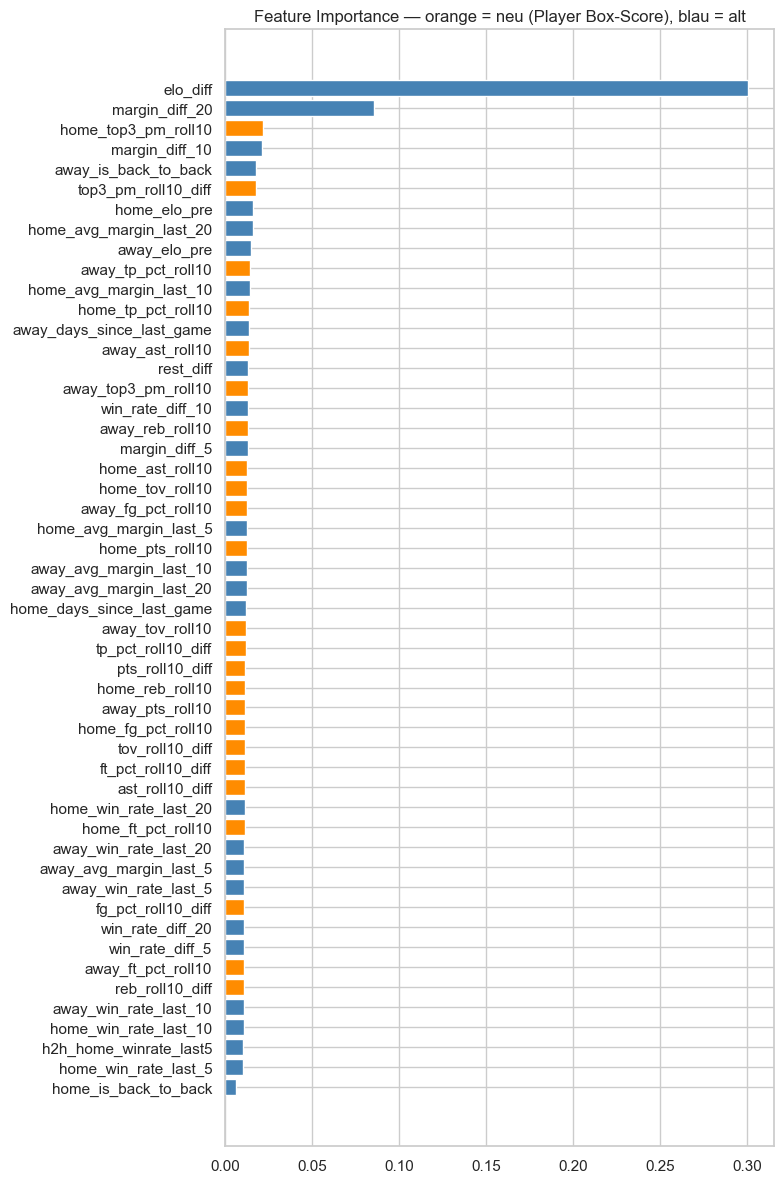


Durchschnittliche Importance — alte Features: 0.0259
Durchschnittliche Importance — neue Features: 0.0126


In [10]:
imp = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': model_new.feature_importances_,
    'is_new': [f in PLAYER_FEATURES for f in ALL_FEATURES],
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 12))
colors = ['darkorange' if new else 'steelblue' for new in imp.is_new]
ax.barh(imp.feature, imp.importance, color=colors)
ax.set_title('Feature Importance — orange = neu (Player Box-Score), blau = alt')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'\nDurchschnittliche Importance — alte Features: {imp[~imp.is_new].importance.mean():.4f}')
print(f'Durchschnittliche Importance — neue Features: {imp[imp.is_new].importance.mean():.4f}')

## 10. Ergebnis & naechste Schritte

Wenn die neue Accuracy hoeher ist als die alte (typisch 1-2 Prozentpunkte), haben sich die Player-Features gelohnt.

**Was als naechstes Sinn macht:**
- **Star-Verfuegbarkeit**: Hat der Top-Scorer der letzten 5 Spiele auch heute >0 Minuten? (vorsichtig: braucht echte Roster-Info, sonst Leakage)
- **Hyperparameter-Tuning** (Optuna) auf dem erweiterten Feature-Set
- **Walk-Forward-Backtest** (Notebook 04) mit dem neuen Datensatz wiederholen
- **Code in `src/` modularisieren** und README polieren